Using p range: [0.750000, 0.890000]  (N=29)


/home/kataoka/anaconda3/envs/pyfssa_env/lib/python3.8/site-packages/fssa/fssa.py:165: RuntimeWarning: rho_c is out of range
  warnings.warn("rho_c is out of range", RuntimeWarning)


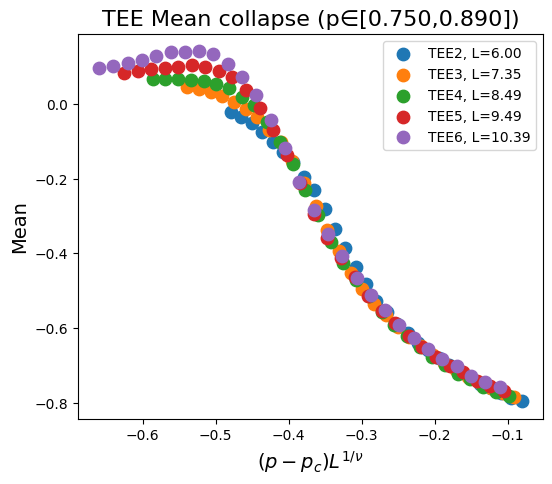

/home/kataoka/anaconda3/envs/pyfssa_env/lib/python3.8/site-packages/fssa/fssa.py:505: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(varco)), varco


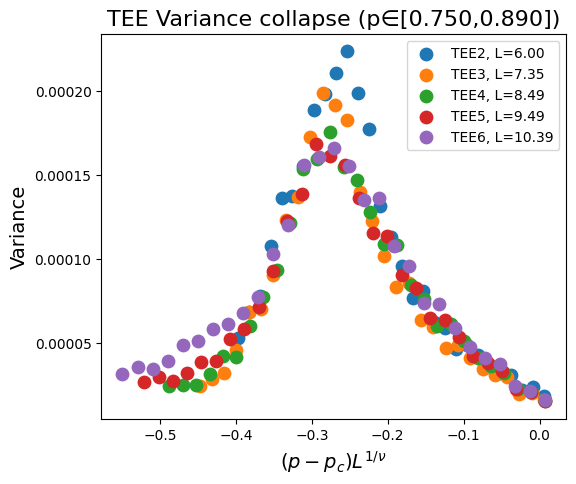

=== 平均 FSS ===
pc = 0.9182746825939381 ± 0.2381562191897394
nu = 1.712896285806134 ± 2.722409567007783
zeta = 0.1218882271750743 ± 1.0615999606188735
S (mean) = 354.2519578097946

=== 分散 FSS ===
pc = 0.8881415553803693 ± 0.013688301480853666
nu = 1.6953619210063078 ± nan
zeta = 3.4620151929655814 ± nan
S (var)  = 0.20200660259300812


In [1]:
import numpy as np
import fssa
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ======================
# 設定
# ======================
gamma = 0.5

# L と TEE キー
# L_list は FSSA のスケール長 (L) を入れる。ここでは sqrt(セル数) を使用。
L_list = [np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
TEE_keys = ['TEE2', 'TEE3', 'TEE4', 'TEE5', 'TEE6']

#L_list = [np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
#TEE_keys = ['TEE2', 'TEE3', 'TEE4', 'TEE5', 'TEE6']

#L_list = [np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
#TEE_keys = ['TEE3', 'TEE4', 'TEE5', 'TEE6']

# データファイル
npz_path = "Lx_24_Nd_500_NT_34560_px_0.0_MPI_hexagonal6.npz"

# カラーマップ
cmap = cm.get_cmap('gnuplot', 4)

# ======================
# p の使用範囲の指定（いずれか1つを有効に）
# ======================
# 方式A: 値で指定（例: 0.30 <= p <= 0.90）
use_by_value = True
pmin, pmax = 0.75, 0.89

# 方式B: 連続インデックスで指定（例: 5〜45 まで）
idx_slice = None  # 例: slice(5, 46)

# 方式C: 個別インデックスのリスト（例: 偶数番だけ）
idx_list = None   # 例: [0, 2, 4, 6, 8]

# ======================
# データ読み込み
# ======================
data = np.load(npz_path)
p_all = data['pg']  # 全 p
# a_mean, da_mean, a_var, da_var を先に作り、あとで列方向に同じマスクを適用
a_mean = np.array([data[f'{k}_ave'] for k in TEE_keys], dtype=float)       # shape=(nL, nP)
da_mean = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma
a_var  = np.array([data[f'{k}_var'] for k in TEE_keys], dtype=float)
da_var = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma  # 仮に同じ誤差を使用

# ======================
# マスク作成
# ======================
if use_by_value:
    mask = (p_all >= pmin) & (p_all <= pmax)
elif idx_slice is not None:
    mask = np.zeros_like(p_all, dtype=bool)
    mask[idx_slice] = True
elif idx_list is not None:
    mask = np.zeros_like(p_all, dtype=bool)
    mask[np.array(idx_list, dtype=int)] = True
else:
    mask = np.ones_like(p_all, dtype=bool)  # 全部使う

# 安全チェック
if not np.any(mask):
    raise ValueError("選択マスクが空です。p の範囲やインデックス指定を見直してください。")

# マスク適用（列方向＝p軸に沿って揃える）
p_use = p_all[mask]
a_mean_sel  = a_mean[:,  mask]
da_mean_sel = da_mean[:, mask]
a_var_sel   = a_var[:,   mask]
da_var_sel  = da_var[:,  mask]

print(f"Using p range: [{p_use.min():.6f}, {p_use.max():.6f}]  (N={p_use.size})")

# ======================
# 平均値 FSS
# ======================
ret_mean = fssa.autoscale(L_list, p_use, a_mean_sel, da_mean_sel,
                          rho_c0=0.86, nu0=1.82, zeta0=2.9)
xs_mean, ys_mean, dys_mean = fssa.scaledata(L_list, p_use, a_mean_sel, da_mean_sel,
                                            ret_mean.rho, ret_mean.nu, ret_mean.zeta)

# ----------------------
# 平均のプロット
# ----------------------
fig, ax = plt.subplots(figsize=(6,5))
for i, (L, key) in enumerate(zip(L_list, TEE_keys)):
    ax.scatter(xs_mean.T[:, i], ys_mean.T[:, i],
               label=f'{key}, L={L:.2f}', s=80)
ax.set_xlabel(r'$(p-p_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Mean', fontsize=14)
ax.legend()
plt.title(f"TEE Mean collapse (p∈[{p_use.min():.3f},{p_use.max():.3f}])", fontsize=16)

plt.savefig("TEE_mean.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# ======================
# 分散 FSS
# ======================
ret_var = fssa.autoscale(L_list, p_use, a_var_sel, da_var_sel,
                         rho_c0=0.88, nu0=1.61, zeta0=3.5)
xs_var, ys_var, dys_var = fssa.scaledata(L_list, p_use, a_var_sel, da_var_sel,
                                         ret_var.rho, ret_var.nu, ret_var.zeta)

# ----------------------
# 分散のプロット
# ----------------------
fig, ax = plt.subplots(figsize=(6,5))
for i, (L, key) in enumerate(zip(L_list, TEE_keys)):
    ax.scatter(xs_var.T[:, i], ys_var.T[:, i],
               label=f'{key}, L={L:.2f}', s=80)
ax.set_xlabel(r'$(p-p_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Variance', fontsize=14)
ax.legend()
plt.title(f"TEE Variance collapse (p∈[{p_use.min():.3f},{p_use.max():.3f}])", fontsize=16)

plt.savefig("TEE_variance.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# ======================
# 結果表示
# ======================
print("=== 平均 FSS ===")
print("pc =", ret_mean.rho, "±", ret_mean.drho)
print("nu =", ret_mean.nu,  "±", ret_mean.dnu)
print("zeta =", ret_mean.zeta, "±", ret_mean.dzeta)
print("S (mean) =", fssa.quality(xs_mean, ys_mean, dys_mean))

print("\n=== 分散 FSS ===")
print("pc =", ret_var.rho, "±", ret_var.drho)
print("nu =", ret_var.nu,  "±", ret_var.dnu)
print("zeta =", ret_var.zeta, "±", ret_var.dzeta)
print("S (var)  =", fssa.quality(xs_var, ys_var, dys_var))

Best over grid (nu fixed=1.6159206560600108): pc≈0.882500, zeta≈3.5125, S≈0.1841


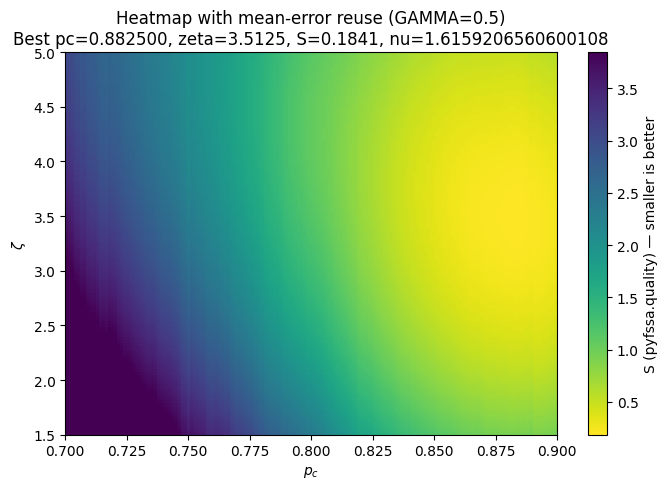

In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
import numpy as np
import fssa
import matplotlib.pyplot as plt

# ======================
# 入力と基本設定
# ======================
npz_path = "Lx_24_Nd_500_NT_17280_px_0.0_MPI_hexagonal6.npz"
L_list   = [np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
TEE_cols = [2, 3, 4, 5, 6]    # TEE1..TEE6 を使用

# p窓
pc_min, pc_max = 0.75, 0.89

# ---- 固定 ν ----
NU_FIXED = 1.6159206560600108

# 探索レンジ
PC_RANGE   = (0.7, 0.9)
ZETA_RANGE = (1.5,  5.0)
N_PC, N_ZETA = 161, 121

# 誤差スケール（平均err流用時の任意係数）
GAMMA = 0.5   # (=1で素の流用。0.5にすると重み×4になるので注意)

# 誤差フロア（ゼロ重み/過小見積りの暴走回避）
ERR_FLOOR_REL = 1e-3

# ======================
# データ読み込み（variance と "平均の誤差を流用"）
# ======================
dat = np.load(npz_path)
pg = dat["pg"].astype(float)

def key(c): return f"TEE{c}"
a_var   = np.array([dat[f"{key(c)}_var"] for c in TEE_cols], float)       # shape=(nL,nP)
# ここがポイント：分散の誤差に「平均の誤差」を流用
da_mean = np.array([dat[f"{key(c)}_err"] for c in TEE_cols], float) * GAMMA
da_var  = da_mean.copy()

# --- p 窓 ---
mask = (pg >= pc_min) & (pg <= pc_max)
if not np.any(mask):
    raise ValueError("p窓にデータがありません。pc_min/max を見直してください。")

pg_use     = pg[mask]
a_var_use  = a_var[:,  mask]
da_var_use = da_var[:, mask]

# --- p を昇順に並べる ---
order = np.argsort(pg_use)
pg_use     = pg_use[order]
a_var_use  = a_var_use[:,  order]
da_var_use = da_var_use[:, order]

# --- 誤差フロア ---
eps = ERR_FLOOR_REL * np.nanmedian(np.abs(a_var_use))
da_var_use = np.maximum(da_var_use, eps)

# ======================
# (p_c, ζ) グリッドで S=quality を評価（νは固定）
# ======================
pc_vals   = np.linspace(*PC_RANGE,   N_PC)
zeta_vals = np.linspace(*ZETA_RANGE, N_ZETA)

S_grid = np.full((N_ZETA, N_PC), np.nan, dtype=float)
bestS, best_pc, best_zeta = np.inf, None, None

for iz, zeta in enumerate(zeta_vals):
    for jp, pc in enumerate(pc_vals):
        try:
            xs, ys, dys = fssa.scaledata(L_list, pg_use, a_var_use, da_var_use,
                                         pc, NU_FIXED, zeta)
            S = fssa.quality(xs, ys, dys)
        except Exception:
            S = np.inf
        S_grid[iz, jp] = S
        if np.isfinite(S) and S < bestS:
            bestS, best_pc, best_zeta = S, pc, zeta

print(f"Best over grid (nu fixed={NU_FIXED}): "
      f"pc≈{best_pc:.6f}, zeta≈{best_zeta:.4f}, S≈{bestS:.4g}")

# ======================
# 可視化（外れ値で真っ黒回避のため上限クリップは任意）
# ======================
plt.figure(figsize=(7,5))
extent = [pc_vals[0], pc_vals[-1], zeta_vals[0], zeta_vals[-1]]
# 95%パーセンタイルでカラーバー上限クリップ（任意）
finite_S = S_grid[np.isfinite(S_grid)]
vmax = np.percentile(finite_S, 95) if finite_S.size else None
im = plt.imshow(S_grid, extent=extent, origin='lower', aspect='auto',
                cmap="viridis_r", vmin=np.nanmin(S_grid), vmax=vmax)
plt.colorbar(im, label="S (pyfssa.quality) — smaller is better")
plt.xlabel(r"$p_c$")
plt.ylabel(r"$\zeta$")
plt.title(f"Heatmap with mean-error reuse (GAMMA={GAMMA})\n"
          f"Best pc={best_pc:.6f}, zeta={best_zeta:.4f}, S={bestS:.4g}, nu={NU_FIXED}")
plt.tight_layout()
plt.savefig("S_heatmap_meanErrReuse_fixed_nu.png", dpi=300)
plt.show()

# 保存
np.savez("Sgrid_meanErrReuse_fixednu.npz",
         pc_vals=pc_vals, zeta_vals=zeta_vals, S_grid=S_grid,
         nu_fixed=NU_FIXED, pc_range=PC_RANGE, zeta_range=ZETA_RANGE,
         pg_window=(pc_min, pc_max),
         L_list=np.array(L_list), TEE_cols=np.array(TEE_cols),
         gamma=GAMMA, err_floor_rel=ERR_FLOOR_REL)


In [1]:
import numpy as np

fname = "Lx_24_Nd_500_NT_17280_px_0.0_MPI_hexagonal6.npz"

# npzファイルを開く
data = np.load(fname)

# キー一覧を表示
print("keys:", data.files)

# 各キーの shape や dtype を確認
for k in data.files:
    arr = data[k]
    print(f"{k}: shape={arr.shape}, dtype={arr.dtype}")

# 例えば pg をちょっと見る
print("pg[:10] =", data["pg"][:10])


keys: ['pg', 'TEE1_ave', 'TEE1_err', 'TEE1_var', 'TEE2_ave', 'TEE2_err', 'TEE2_var', 'TEE3_ave', 'TEE3_err', 'TEE3_var', 'TEE4_ave', 'TEE4_err', 'TEE4_var', 'TEE5_ave', 'TEE5_err', 'TEE5_var', 'TEE6_ave', 'TEE6_err', 'TEE6_var']
pg: shape=(21,), dtype=float64
TEE1_ave: shape=(21,), dtype=float64
TEE1_err: shape=(21,), dtype=float64
TEE1_var: shape=(21,), dtype=float64
TEE2_ave: shape=(21,), dtype=float64
TEE2_err: shape=(21,), dtype=float64
TEE2_var: shape=(21,), dtype=float64
TEE3_ave: shape=(21,), dtype=float64
TEE3_err: shape=(21,), dtype=float64
TEE3_var: shape=(21,), dtype=float64
TEE4_ave: shape=(21,), dtype=float64
TEE4_err: shape=(21,), dtype=float64
TEE4_var: shape=(21,), dtype=float64
TEE5_ave: shape=(21,), dtype=float64
TEE5_err: shape=(21,), dtype=float64
TEE5_var: shape=(21,), dtype=float64
TEE6_ave: shape=(21,), dtype=float64
TEE6_err: shape=(21,), dtype=float64
TEE6_var: shape=(21,), dtype=float64
pg[:10] = [0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79]


In [2]:
import numpy as np
from collections import defaultdict
import re, math

# --- 1) slurmログをパースして {pg: list of [TEE1..TEE6]} を作る ---
bucket = defaultdict(list)
pat = re.compile(r"pg=\s*([0-9.]+).*?TEE1=\s*([-0-9.]+).*?TEE2=\s*([-0-9.]+).*?"
                 r"TEE3=\s*([-0-9.]+).*?TEE4=\s*([-0-9.]+).*?TEE5=\s*([-0-9.]+).*?TEE6=\s*([-0-9.]+)")
with open("slurm-2647584.out") as f:
    for line in f:
        m = pat.search(line)
        if m:
            pg = float(m.group(1))
            tees = list(map(float, m.groups()[1:]))  # 6個
            bucket[pg].append(tees)

pg = np.array(sorted(bucket.keys()))
stack = np.array([bucket[p] for p in pg], dtype=float)   # shape=(nP, nSamples, 6)

# --- 2) 分散とそのブートストラップ標準誤差を推定 ---
def bootstrap_var(x, nboot=1000, rng=np.random.default_rng(0)):
    x = np.asarray(x)
    n = len(x)
    if n <= 3:
        return np.var(x, ddof=1), np.nan  # サンプル少な過ぎ
    vs = []
    for _ in range(nboot):
        idx = rng.integers(0, n, n)
        vs.append(np.var(x[idx], ddof=1))
    return np.var(x, ddof=1), np.std(vs, ddof=1)

var6  = np.zeros((len(pg), 6))
dvar6 = np.zeros((len(pg), 6))
for i in range(len(pg)):
    for k in range(6):
        v, dv = bootstrap_var(stack[i,:,k], nboot=1000)
        var6[i,k]  = v
        dvar6[i,k] = dv

# これを npz に保存（pyfssa にそのまま渡せる形）
out = {"pg": pg}
for k in range(6):
    out[f"TEE{k+1}_var"] = var6[:,k]
    out[f"TEE{k+1}_err"] = dvar6[:,k]          # ← 平均の誤差ではなく、分散の標準誤差！
np.savez_compressed("from_log_var_boot.npz", **out)


In [18]:
import numpy as np

fname = "from_log_var_boot.npz"

# npzファイルを開く
data = np.load(fname)

# キー一覧を表示
print("keys:", data.files)

# 各キーの shape や dtype を確認
for k in data.files:
    arr = data[k]
    #print(f"{k}: shape={arr.shape}, dtype={arr.dtype}")

# 例えば pg をちょっと見る
print("pg =", data["pg"][:21])
print("TEE2_var =", data["TEE2_var"][:21])
print("TEE2_err =", data["TEE2_err"][:21])
print("TEE3_var =", data["TEE3_var"][:21])
print("TEE3_err =", data["TEE3_err"][:21])
print("TEE4_var =", data["TEE4_var"][:21])
print("TEE4_err =", data["TEE4_err"][:21])

keys: ['pg', 'TEE1_var', 'TEE1_err', 'TEE2_var', 'TEE2_err', 'TEE3_var', 'TEE3_err', 'TEE4_var', 'TEE4_err', 'TEE5_var', 'TEE5_err', 'TEE6_var', 'TEE6_err']
pg = [0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83
 0.84 0.85 0.86 0.87 0.88 0.89 0.9 ]
TEE2_var = [0.00037377 0.00056611 0.0006318  0.00091905 0.00129875 0.00200333
 0.00279115 0.00453735 0.00594738 0.00758096 0.00759114 0.00684237
 0.00472615 0.00307917 0.00274834 0.00192102 0.00153818 0.00115939
 0.00097333 0.00067782 0.00046904]
TEE2_err = [2.52418238e-05 4.27488296e-05 5.14104226e-05 6.63318993e-05
 9.05290671e-05 1.58888470e-04 1.87259147e-04 3.00359581e-04
 3.79392256e-04 4.41402051e-04 4.43306156e-04 4.61853135e-04
 3.01929687e-04 1.68085999e-04 1.56770371e-04 1.18221242e-04
 9.41573867e-05 7.73609349e-05 5.84898764e-05 3.99925612e-05
 2.86375563e-05]
TEE3_var = [0.00051691 0.00064192 0.00068061 0.0007824  0.00101593 0.00130398
 0.0018448  0.00322954 0.00543799 0.0080001  0.01003677 0.01090978
 0.00

In [4]:
import numpy as np

# ===== 入力 =====
AVE_NPZ = "Lx_24_Nd_500_NT_17280_px_0.0_MPI_hexagonal6.npz"   # 例: 'pg', 'TEE{i}_ave', 'TEE{i}_ave_err' を含む
VAR_NPZ = "from_log_var_boot.npz"   # 例: 'pg', 'TEE{i}_var', 'TEE{i}_err'     を含む
OUT_NPZ = "TEE_merged.npz"

# あなたが指定するサイズ（数値）。例：TEE2=√12, TEE3=√18 など
SIZE = {
    "TEE1": np.sqrt(6),
    "TEE2": np.sqrt(12),
    "TEE3": np.sqrt(18),
    "TEE4": np.sqrt(24),   # ←必要な値を入れてください
    "TEE5": np.sqrt(30),
    "TEE6": np.sqrt(36),
}

# ===== マージ処理 =====
za = np.load(AVE_NPZ)
zv = np.load(VAR_NPZ)

pg_a = za["pg"]
pg_v = zv["pg"]
if not np.allclose(pg_a, pg_v):
    raise ValueError("pg が ave と var で一致していません。揃えてから実行してください。")

out = {"pg": pg_a}

for i in range(1, 7):
    key = f"TEE{i}"

    # サイズ（あなた指定の数値を保存）
    if key not in SIZE:
        raise KeyError(f"SIZE に {key} の指定がありません。")
    out[f"{key}_size"] = float(SIZE[key])

    # ave と誤差（誤差が無ければスキップでOK）
    out[f"{key}_ave"] = za[f"{key}_ave"]
    if f"{key}_err" in za:
        out[f"{key}_ave_err"] = za[f"{key}_err"]

    # var と誤差（あなたの形式に合わせて *_err を拾う）
    out[f"{key}_var"] = zv[f"{key}_var"]
    if f"{key}_err" in zv:               # 例：分散のブート誤差を 'TEE{i}_err' で保存している
        out[f"{key}_var_err"] = zv[f"{key}_err"]
    elif f"{key}_err" in zv:         # 別名対応
        out[f"{key}_var_err"] = zv[f"{key}_err"]

# 保存
np.savez_compressed(OUT_NPZ, **out)
print(f"Wrote {OUT_NPZ} with keys:", list(out.keys()))


Wrote TEE_merged.npz with keys: ['pg', 'TEE1_size', 'TEE1_ave', 'TEE1_ave_err', 'TEE1_var', 'TEE1_var_err', 'TEE2_size', 'TEE2_ave', 'TEE2_ave_err', 'TEE2_var', 'TEE2_var_err', 'TEE3_size', 'TEE3_ave', 'TEE3_ave_err', 'TEE3_var', 'TEE3_var_err', 'TEE4_size', 'TEE4_ave', 'TEE4_ave_err', 'TEE4_var', 'TEE4_var_err', 'TEE5_size', 'TEE5_ave', 'TEE5_ave_err', 'TEE5_var', 'TEE5_var_err', 'TEE6_size', 'TEE6_ave', 'TEE6_ave_err', 'TEE6_var', 'TEE6_var_err']


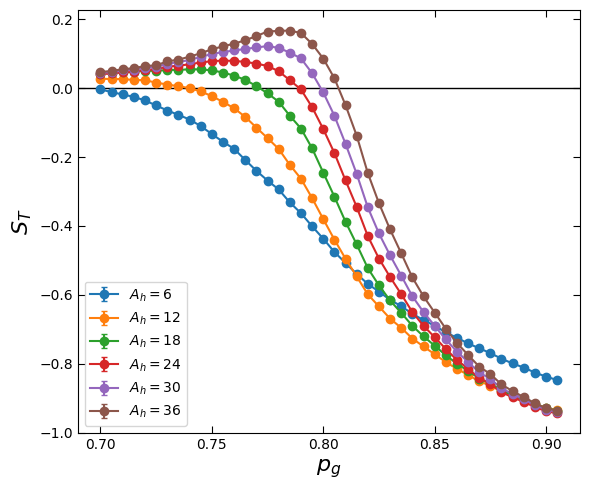

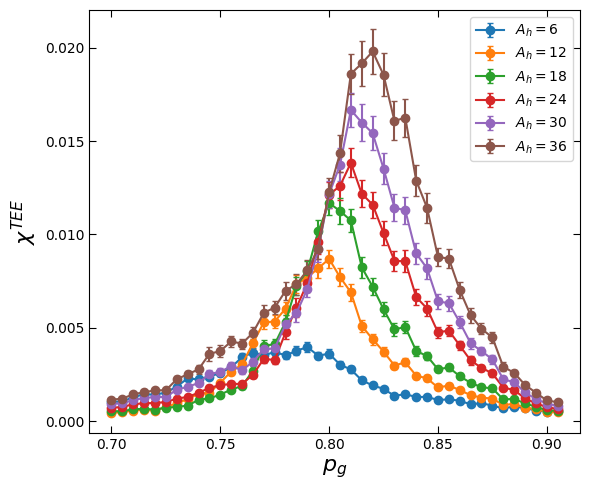

In [2]:
# ave/var を誤差つきで可視化（凡例は *_size）
import numpy as np
import matplotlib.pyplot as plt

NPZ_PATH = "TEE_merged.npz"   # ここをあなたのファイルに
SERIES   = [1, 2, 3, 4, 5, 6] # 描きたい TEE 番号

z  = np.load(NPZ_PATH)
pg = z["pg"].astype(float)

def get(key):  # 存在チェックつき取得
    if key not in z:
        raise KeyError(f"'{key}' が {NPZ_PATH} にありません")
    return z[key].astype(float)


labels = [r"$A_h=6$", "$A_h=12$", r"$A_h=18$", r"$A_h=24$", r"$A_h=30$", r"$A_h=36$"]

# SERIES と labels の対応を作る（順番対応）
if len(labels) < len(SERIES):
    raise ValueError("labels の数が SERIES より少ないです。対応する分だけ用意してください。")
label_map = {s: labels[idx] for idx, s in enumerate(SERIES)}

# --- ave ± err ---
fig, ax = plt.subplots(figsize=(6,5))
for i in SERIES:
    ave    = get(f"TEE{i}_ave")
    aveerr = get(f"TEE{i}_ave_err")
    ax.errorbar(pg, ave, yerr=aveerr, fmt='o-', capsize=2, label=label_map[i])

ax.set_xlabel("$p_g$",fontsize=16)
ax.set_ylabel("$S_{T}$",fontsize=16)
#ax.set_title("Average with error")
ax.legend(title="")

# 目盛りはメジャーのみを内側へ（補助目盛りは使わない）
ax.tick_params(direction='in', which='major', top=True, right=True, length=5)
ax.minorticks_off()  # 補助目盛を完全に無効化
ax.tick_params(which='minor', bottom=False, left=False, top=False, right=False)
ax.axhline(y=0, color='k', lw=1)
ax.set_ylim(-1)
fig.tight_layout()
fig.savefig("TEE_ave_px_0.png", dpi=300, bbox_inches="tight")
plt.show()


# --- var ± err ---
fig, ax = plt.subplots(figsize=(6,5))
for i in SERIES:
    var    = get(f"TEE{i}_var")
    varerr = get(f"TEE{i}_var_err")
    if len(var) != len(pg) or len(varerr) != len(pg):
        raise ValueError(f"TEE{i} の長さが pg と一致しません")
    ax.errorbar(pg, var, yerr=varerr, fmt='o-', capsize=2, label=label_map[i])
ax.set_xlabel("$p_g$",fontsize=16)
ax.set_ylabel("$\chi^{TEE}$",fontsize=16)

#ax.set_title("Average with error")
ax.legend(title="")

# 目盛りはメジャーのみを内側へ（補助目盛りは使わない）
ax.tick_params(direction='in', which='major', top=True, right=True, length=5)
ax.minorticks_off()  # 補助目盛を完全に無効化
ax.tick_params(which='minor', bottom=False, left=False, top=False, right=False)

fig.tight_layout()
fig.savefig("TEE_var_px_0.png", dpi=300, bbox_inches="tight")
plt.show()


[coarse] pc0=0.855220, nu0=1.0400, S=6.0951
TEE1-6(参考)

=== Variance FSS (fss_merged.npz) ===
['4.24', '6.00', '7.35', '8.49', '9.49', '10.39']
pc   = 0.896086390 ± 0.003206963
nu   = 2.318182132 ± 0.073998433
zeta = 4.449707446 ± 1.658853038
S     = 3.477727


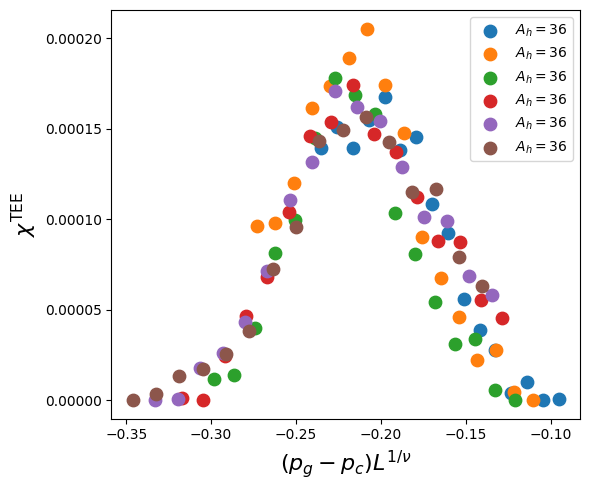

In [5]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt
import fssa
from scipy.optimize import curve_fit

# ======================
# 入力
# ======================
npz_path = "TEE_merged.npz"

# --- L は √Ah（あなたの指定） ---
AH = {1:18, 2:36, 3:54, 4:72, 5:90, 6:108}

# まずは補正の効きやすい小サイズを外して安定化
TEE_cols = [1,2,3,4,5,6]        # ← 成功したら [2,3,4,5,6] に戻す
L_list   = [np.sqrt(AH[c]) for c in TEE_cols]

# ζを固定（ピーク高さの独立推定 ≈ 1.83 を採用）
FIX_ZETA = False
ZETA_VAL = 3.4

# 誤差フロア（過大にしない）
ERR_FLOOR_REL = 1e-4

# コラプスの |x| 窓（描画時）
S_WINDOW = 2.0

# ======================
# データ読み込み（Var とそのSE）
# ======================
dat = np.load(npz_path, allow_pickle=True)
pg = np.asarray(dat["pg"], float)

def k(c, suf): return f"TEE{c}_{suf}"
A  = np.array([dat[k(c,"var")]     for c in TEE_cols], float)  # shape=(nL,nP)
dA = np.array([dat[k(c,"var_err")] for c in TEE_cols], float)

# ======================
# 放物線で各サイズの g*_L を推定 → 左右対称の p 窓を決定
# ======================
def quad(x,a,b,c): return a*x**2 + b*x + c
def gstar_parabola(pg,y,dy):
    eps = max(1e-12, np.nanmedian(np.abs(y))*1e-6)
    dy  = np.where((dy>0)&np.isfinite(dy), dy, eps)
    i   = int(np.nanargmax(y))
    lo,hi = max(0,i-2), min(len(pg), i+3)
    x,yy,dyy = pg[lo:hi], y[lo:hi], dy[lo:hi]
    if len(x) < 3: return pg[i]
    (Aq,Bq,Cq),_ = curve_fit(quad, x, yy, sigma=dyy, absolute_sigma=True, maxfev=20000)
    gx = -Bq/(2*Aq)
    return gx if (pg.min() <= gx <= pg.max()) else pg[i]

gstars = np.array([gstar_parabola(pg, A[i], dA[i]) for i in range(len(TEE_cols))])
pc_center = float(gstars.mean())
dpg = max(0.04, float(gstars.std()) + 0.02)     # ← 肩が両側入る幅
mask = (pg >= pc_center - dpg) & (pg <= pc_center + dpg)

# 窓で切って昇順に並び替え
pg_use = pg[mask]; order = np.argsort(pg_use)
pg_use = pg_use[order]
A_use  = A[:,  mask][:, order]
dA_use = dA[:, mask][:, order]

# （任意）基線オフセット除去：窓内で最小値を引くと S が改善する系がある
A_base = A_use.min(axis=1, keepdims=True)
A_use  = A_use - A_base

# 誤差フロア（控えめに）
eps = ERR_FLOOR_REL * np.nanmedian(np.abs(A_use))
dA_use = np.maximum(dA_use, eps)

# ======================
# 粗探索 → autoscale（ζ固定）
# ======================
ZETA = ZETA_VAL if FIX_ZETA else 2.0
rhos = np.linspace(pc_center-0.03, pc_center+0.05, 33)
nus  = np.linspace(1.0, 2.2, 31)

bestS, rho0, nu0 = np.inf, None, None
for rh in rhos:
    for nv in nus:
        xs, ys, dys = fssa.scaledata(L_list, pg_use, A_use, dA_use, rh, nv, ZETA)
        S = fssa.quality(xs, ys, dys)
        if np.isfinite(S) and S < bestS:
            bestS, rho0, nu0 = S, rh, nv
print(f"[coarse] pc0={rho0:.6f}, nu0={nu0:.4f}, S={bestS:.4f}")
print("TEE1-6(参考)")

ret = fssa.autoscale(L_list, pg_use, A_use, dA_use,
                     rho_c0=rho0, nu0=nu0, zeta0=ZETA)
if FIX_ZETA:
    ret.zeta  = ZETA
    ret.dzeta = 0.0

# スケール変換（コラプス座標）と評価関数
xs, ys, dys = fssa.scaledata(L_list, pg_use, A_use, dA_use,
                             ret.rho, ret.nu, ret.zeta)
from fssa import quality
S_val = quality(xs, ys, dys)

# ======================
# 結果表示
# ======================
print("\n=== Variance FSS (fss_merged.npz) ===")
print([f"{L:.2f}" for L in L_list])
print(f"pc   = {ret.rho:.9f} ± {getattr(ret, 'drho', np.nan):.9f}")
print(f"nu   = {ret.nu:.9f} ± {getattr(ret, 'dnu',  np.nan):.9f}")
print(f"zeta = {ret.zeta:.9f} ± {getattr(ret, 'dzeta', np.nan):.9f}" + (" (FIXED)" if FIX_ZETA else ""))
print(f"S     = {S_val:.6f}")

# ======================
# プロット（コラプス後）
# ======================
fig, ax = plt.subplots(figsize=(6,5))
for i, L in enumerate(L_list):
    #ax.plot(xs.T[:, i], ys.T[:, i], 'o', label=f"Ah={int(AH[TEE_cols[i]])}")
    ax.scatter(xs.T[:, i], ys.T[:, i],
           label=label, s=80)
ax.set_xlabel(r"$(p_g-p_c)L^{1/\nu}$",fontsize=16)
ax.set_ylabel(r"$\chi^{\rm TEE}$",fontsize=16)
ax.legend(fontsize=10)
fig.tight_layout()
fig.savefig("TEE_collapse_px_0.png", dpi=300, bbox_inches='tight')
plt.show()


TEE1-6(参考)


=== Variance FSS===
[4.242640687119285, 6.0, 7.3484692283495345, 8.48528137423857, 9.486832980505138, 10.392304845413264]
pc   = 0.882437210 ± 0.015241788
nu   = 1.869871162 ± 1.584216536
zeta = 3.315290810 ± 2.952992566
S     = 5.680639


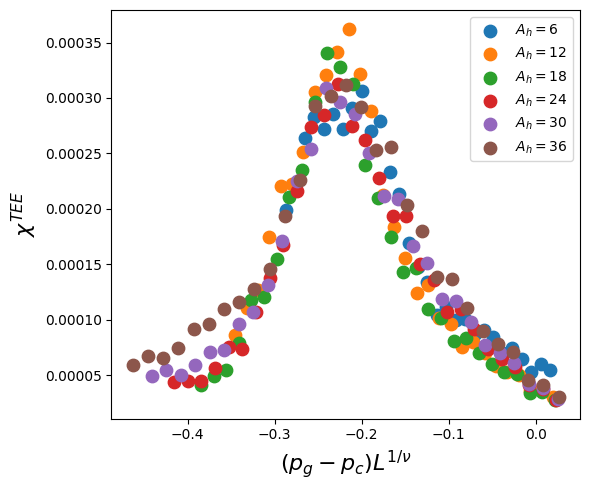

In [10]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
import numpy as np
import fssa
import matplotlib.pyplot as plt

# ======================
# 入力
# ======================
npz_path = "TEE_merged.npz"   # ブートストラップで作ったnpz
# Lは √(セル数) を例として使用（あなたの流儀に合わせて変更）
L_list   = [np.sqrt(18), np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
#L_list   = [np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
# TEEのどれを使うか（L_listと同数・同順に合わせる）
TEE_cols = [1, 2, 3, 4, 5, 6]  # = TEE1..TEE6 を使う例
#TEE_cols = [3, 4, 5, 6]  # = TEE3..TEE6 を使う例


# クリティカル窓（まず少し広め→収束後に狭めるのが吉）
pc_min = 0.75
pc_max = 0.89

# ζを固定すると相関が切れて安定（推奨）
FIX_ZETA = False
ZETA_VAL = 3.6
# ζを自由にしたい場合は False にして下の zeta0 を初期値とする
zeta0    = 3.3


rho_c0, nu0 = 0.87, 1.76

#Best
#pc_min = 0.75
#pc_max = 0.89
#rho_c0, nu0,zeta0 = 0.87, 1.74
#zeta0 = 3.78 (False) 
#pc   = 0.890030137 ± 0.005939050
#nu   = 1.761236425 ± 0.093202186
#zeta = 3.626721887 ± 0.703192104
#S     = 4.571723


# 誤差フロア（ゼロ重み回避）
ERR_FLOOR_REL = 1e-3

# ======================
# データ読み込み（分散とそのSE）
# ======================
dat = np.load(npz_path)
pg = dat["pg"]

# 例：TEE2..TEE6 を使う
def col_to_key(c): return f"TEE{c}"
a_var  = np.array([dat[f"{col_to_key(c)}_var"] for c in TEE_cols], float)  # shape=(nL,nP)
da_var = np.array([dat[f"{col_to_key(c)}_var_err"] for c in TEE_cols], float)

# --- p窓 ---
mask = (pg >= pc_min) & (pg <= pc_max)
pg_use     = pg[mask]
a_var_use  = a_var[:,  mask]
da_var_use = da_var[:, mask]

# --- p を昇順に並び替え（重要） ---
order = np.argsort(pg_use)
pg_use     = pg_use[order]
a_var_use  = a_var_use[:,  order]
da_var_use = da_var_use[:, order]

# --- 誤差フロア ---
eps = ERR_FLOOR_REL * np.nanmedian(np.abs(a_var_use))
da_var_use = np.maximum(da_var_use, eps)

# ======================
# 粗探索で初期値（pc, nu）を作る
# ======================
"""rhos = np.linspace(pg_use.min(), pg_use.max(), 31)
nus  = np.linspace(0.8, 3.0, 30)
bestS, rho_c0, nu0 = np.inf, None, None

for rh in rhos:
    for nv in nus:
        zeta = ZETA_VAL if FIX_ZETA else zeta0
        xs, ys, dys = fssa.scaledata(L_list, pg_use, a_var_use, da_var_use, rh, nv, zeta)
        S = fssa.quality(xs, ys, dys)
        if S < bestS and np.isfinite(S):
            bestS, rho_c0, nu0 = S, rh, nv

print(f"[coarse] pc0={rho_c0:.6f}, nu0={nu0:.4f}, S={bestS:.4f}")"""

# ======================
# autoscale 本番
# ======================
if FIX_ZETA:
    ret = fssa.autoscale(L_list, pg_use, a_var_use, da_var_use,
                         rho_c0=rho_c0, nu0=nu0, zeta0=zeta0)
    # ζ固定
    ret.zeta  = ZETA_VAL
    ret.dzeta = 0.0
else:
    ret = fssa.autoscale(L_list, pg_use, a_var_use, da_var_use,
                         rho_c0=rho_c0, nu0=nu0, zeta0=zeta0)

# スケール変換（コラプス座標）
xs, ys, dys = fssa.scaledata(L_list, pg_use, a_var_use, da_var_use,
                             ret.rho, ret.nu, ret.zeta)

# 評価関数
from fssa import quality
S_val = quality(xs, ys, dys)

# ======================
# 結果表示
# ======================
print("\n=== Variance FSS===")
print(L_list)
print(f"pc   = {ret.rho:.9f} ± {getattr(ret, 'drho', np.nan):.9f}")
print(f"nu   = {ret.nu:.9f} ± {getattr(ret, 'dnu',  np.nan):.9f}")
print(f"zeta = {ret.zeta:.9f} ± {getattr(ret, 'dzeta', np.nan):.9f}" + (" (FIXED)" if FIX_ZETA else ""))
print(f"S     = {S_val:.6f}")


# ======================
# プロット（コラプス後）
# ======================
fig, ax = plt.subplots(figsize=(6,5))
labels = [r"$A_h=6$", r"$A_h=12$", r"$A_h=18$", r"$A_h=24$", r"$A_h=30$", r"$A_h=36$"]
#labels = [r"$A_h=12$", r"$A_h=18$", r"$A_h=24$", r"$A_h=30$", r"$A_h=36$"]
for i, (L, label) in enumerate(zip(L_list, labels)):
    """ax.errorbar(xs.T[:, i], ys.T[:, i], yerr=dys.T[:, i],
                fmt='o', ms=5, capsize=3, label=label, alpha=0.9)"""
    #ax.plot(xs.T[:, i], ys.T[:, i],'o',label=label, alpha=0.9)
    ax.scatter(xs.T[:, i], ys.T[:, i],label=label, s=80)
ax.set_xlabel(r"$(p_g-p_c)L^{1/\nu}$",fontsize=16)
ax.set_ylabel(r"$\chi^{TEE}$",fontsize=16)
ax.legend( fontsize=10)
ax.grid(False)
fig.tight_layout()
fig.savefig("TEE_collapse_px_0.png", dpi=300, bbox_inches="tight")
plt.show()


/home/kataoka/anaconda3/envs/pyfssa_env/lib/python3.8/site-packages/fssa/fssa.py:165: RuntimeWarning: rho_c is out of range
  warnings.warn("rho_c is out of range", RuntimeWarning)



=== Variance FSS===
[6.0, 7.3484692283495345, 8.48528137423857, 9.486832980505138, 10.392304845413264]
pc   = 0.875635369 ± 0.024322667
nu   = 1.772293143 ± 0.309666019
zeta = 4.148772345 ± 1.130544886
S     = 7.415810


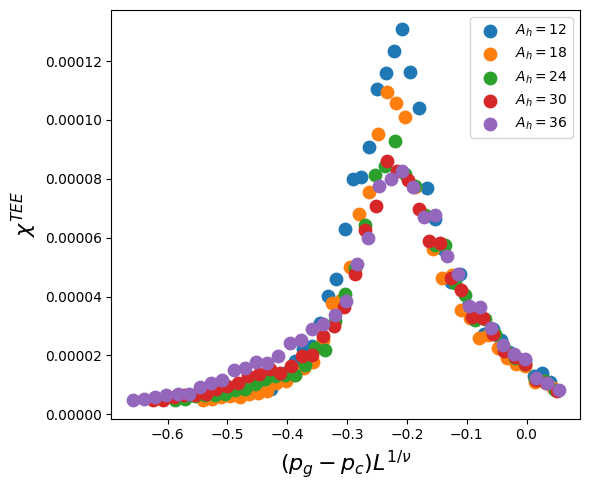

In [9]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
import numpy as np
import fssa
import matplotlib.pyplot as plt

# ======================
# 入力
# ======================
npz_path = "TEE_merged.npz"   # ブートストラップで作ったnpz
# Lは √(セル数) を例として使用（あなたの流儀に合わせて変更）
#L_list   = [np.sqrt(18), np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
L_list   = [np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
# TEEのどれを使うか（L_listと同数・同順に合わせる）
#TEE_cols = [1, 2, 3, 4, 5, 6]  # = TEE1..TEE6 を使う例
TEE_cols = [2, 3, 4, 5, 6]  # = TEE3..TEE6 を使う例


# クリティカル窓（まず少し広め→収束後に狭めるのが吉）
pc_min = 0.7
pc_max = 0.89

# ζを固定すると相関が切れて安定（推奨）
FIX_ZETA = False
ZETA_VAL = 3.58
# ζを自由にしたい場合は False にして下の zeta0 を初期値とする
zeta0    = 3.78

rho_c0, nu0 = 0.87, 1.74

#Best
#pc_min = 0.75
#pc_max = 0.89
#rho_c0, nu0,zeta0 = 0.87, 1.74
#zeta0 = 3.78 (False) 
#pc   = 0.890030137 ± 0.005939050
#nu   = 1.761236425 ± 0.093202186
#zeta = 3.626721887 ± 0.703192104
#S     = 4.571723

# 誤差フロア（ゼロ重み回避）
ERR_FLOOR_REL = 1e-3

# ======================
# データ読み込み（分散とそのSE）
# ======================
dat = np.load(npz_path)
pg = dat["pg"]

# 例：TEE2..TEE6 を使う
def col_to_key(c): return f"TEE{c}"
a_var  = np.array([dat[f"{col_to_key(c)}_var"] for c in TEE_cols], float)  # shape=(nL,nP)
da_var = np.array([dat[f"{col_to_key(c)}_var_err"] for c in TEE_cols], float)

# --- p窓 ---
mask = (pg >= pc_min) & (pg <= pc_max)
pg_use     = pg[mask]
a_var_use  = a_var[:,  mask]
da_var_use = da_var[:, mask]

# --- p を昇順に並び替え（重要） ---
order = np.argsort(pg_use)
pg_use     = pg_use[order]
a_var_use  = a_var_use[:,  order]
da_var_use = da_var_use[:, order]

# --- 誤差フロア ---
eps = ERR_FLOOR_REL * np.nanmedian(np.abs(a_var_use))
da_var_use = np.maximum(da_var_use, eps)

# ======================
# 粗探索で初期値（pc, nu）を作る
# ======================
"""rhos = np.linspace(pg_use.min(), pg_use.max(), 31)
nus  = np.linspace(0.8, 3.0, 30)
bestS, rho_c0, nu0 = np.inf, None, None

for rh in rhos:
    for nv in nus:
        zeta = ZETA_VAL if FIX_ZETA else zeta0
        xs, ys, dys = fssa.scaledata(L_list, pg_use, a_var_use, da_var_use, rh, nv, zeta)
        S = fssa.quality(xs, ys, dys)
        if S < bestS and np.isfinite(S):
            bestS, rho_c0, nu0 = S, rh, nv

print(f"[coarse] pc0={rho_c0:.6f}, nu0={nu0:.4f}, S={bestS:.4f}")"""

# ======================
# autoscale 本番
# ======================
if FIX_ZETA:
    ret = fssa.autoscale(L_list, pg_use, a_var_use, da_var_use,
                         rho_c0=rho_c0, nu0=nu0, zeta0=zeta0)
    # ζ固定
    ret.zeta  = ZETA_VAL
    ret.dzeta = 0.0
else:
    ret = fssa.autoscale(L_list, pg_use, a_var_use, da_var_use,
                         rho_c0=rho_c0, nu0=nu0, zeta0=zeta0)

# スケール変換（コラプス座標）
xs, ys, dys = fssa.scaledata(L_list, pg_use, a_var_use, da_var_use,
                             ret.rho, ret.nu, ret.zeta)

# 評価関数
from fssa import quality
S_val = quality(xs, ys, dys)

# ======================
# 結果表示
# ======================
print("\n=== Variance FSS===")
print(L_list)
print(f"pc   = {ret.rho:.9f} ± {getattr(ret, 'drho', np.nan):.9f}")
print(f"nu   = {ret.nu:.9f} ± {getattr(ret, 'dnu',  np.nan):.9f}")
print(f"zeta = {ret.zeta:.9f} ± {getattr(ret, 'dzeta', np.nan):.9f}" + (" (FIXED)" if FIX_ZETA else ""))
print(f"S     = {S_val:.6f}")


# ======================
# プロット（コラプス後）
# ======================
fig, ax = plt.subplots(figsize=(6,5))
labels = [r"$A_h=12$", r"$A_h=18$", r"$A_h=24$", r"$A_h=30$", r"$A_h=36$"]
#labels = [r"$A_h=12$", r"$A_h=18$", r"$A_h=24$", r"$A_h=30$", r"$A_h=36$"]
for i, (L, label) in enumerate(zip(L_list, labels)):
    """ax.errorbar(xs.T[:, i], ys.T[:, i], yerr=dys.T[:, i],
                fmt='o', ms=5, capsize=3, label=label, alpha=0.9)"""
    #ax.plot(xs.T[:, i], ys.T[:, i],'o', label=label, alpha=0.9)
    ax.scatter(xs.T[:, i], ys.T[:, i],label=label, s=80)
ax.set_xlabel(r"$(p_g-p_c)L^{1/\nu}$",fontsize=16)
ax.set_ylabel(r"$\chi^{TEE}$",fontsize=16)
ax.legend( fontsize=10)
ax.grid(False)
fig.tight_layout()
fig.savefig("TEE_collapse_px_0.png", dpi=300, bbox_inches="tight")
plt.show()


/home/kataoka/anaconda3/envs/pyfssa_env/lib/python3.8/site-packages/fssa/fssa.py:165: RuntimeWarning: rho_c is out of range
  warnings.warn("rho_c is out of range", RuntimeWarning)


Best over grid: pc≈0.870000, zeta≈3.0458, S≈5.017 (nu fixed=1.333)


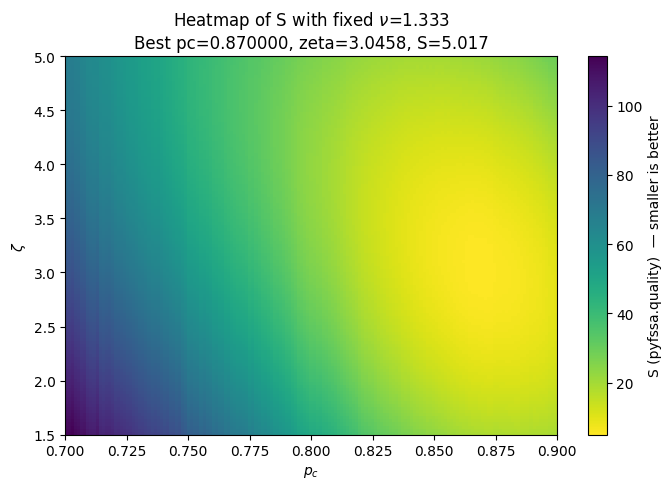

In [40]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
import numpy as np
import fssa
import matplotlib.pyplot as plt

# ======================
# 入力と基本設定
# ======================
npz_path = "TEE_merged.npz"   # あなたの npz
# L はあなたの流儀に合わせて用意（TEE_cols と同数・同順）
# 例: Ah=36,54,72,90,108 → L=sqrt(Ah)
L_list   = [np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
TEE_cols = [2, 3, 4, 5, 6]  # 使う系列（TEE2..TEE6）

# p 窓（あなたのスクリプトに合わせる）
pc_min = 0.75
pc_max = 0.89

# --- ここを "固定ν" にする ---
NU_FIXED = 1.333  # 例: 1.80（必要なら 1.7656 などに変更）

# 探索レンジ（必要に応じて広げる）
PC_RANGE   = (0.7, 0.9)   # pc の探索範囲
ZETA_RANGE = (1.5,  5.0)    # zeta の探索範囲
N_PC, N_ZETA = 161, 121     # グリッド解像度

# 誤差フロア（ゼロ重み回避）
ERR_FLOOR_REL = 1e-3

# ======================
# データ読み込み（variance と SE）
# ======================
dat = np.load(npz_path)
pg = dat["pg"]

def key(c): return f"TEE{c}"
a_var  = np.array([dat[f"{key(c)}_var"]     for c in TEE_cols], float)  # shape=(nL,nP)
da_var = np.array([dat[f"{key(c)}_var_err"] for c in TEE_cols], float)

# --- p 窓 ---
mask = (pg >= pc_min) & (pg <= pc_max)
pg_use     = pg[mask]
a_var_use  = a_var[:,  mask]
da_var_use = da_var[:, mask]

# --- p を昇順に並び替え ---
order = np.argsort(pg_use)
pg_use     = pg_use[order]
a_var_use  = a_var_use[:,  order]
da_var_use = da_var_use[:, order]

# --- 誤差フロア ---
eps = ERR_FLOOR_REL * np.nanmedian(np.abs(a_var_use))
da_var_use = np.maximum(da_var_use, eps)

# ======================
# (pc, zeta) グリッドで S=quality を評価
# ======================
pc_vals   = np.linspace(*PC_RANGE,   N_PC)
zeta_vals = np.linspace(*ZETA_RANGE, N_ZETA)
S_grid = np.empty((N_ZETA, N_PC), float); S_grid[:] = np.nan

best = (np.inf, None, None)

for iz, zeta in enumerate(zeta_vals):
    for jp, pc in enumerate(pc_vals):
        # pyfssa のスケール変換（νは固定 → pc と ζ を走査）
        try:
            xs, ys, dys = fssa.scaledata(L_list, pg_use, a_var_use, da_var_use,
                                         pc, NU_FIXED, zeta)
            S = fssa.quality(xs, ys, dys)  # ← pyfssaベースの評価関数
        except Exception:
            S = np.inf
        S_grid[iz, jp] = S
        if np.isfinite(S) and S < best[0]:
            best = (S, pc, zeta)

Smin, pc_best, zeta_best = best
print(f"Best over grid: pc≈{pc_best:.6f}, zeta≈{zeta_best:.4f}, S≈{Smin:.4g} (nu fixed={NU_FIXED})")

# ======================
# 可視化
# ======================
plt.figure(figsize=(7,5))
extent = [pc_vals[0], pc_vals[-1], zeta_vals[0], zeta_vals[-1]]
im = plt.imshow(S_grid, extent=extent, origin='lower', aspect='auto', cmap="viridis_r")
plt.colorbar(im, label="S (pyfssa.quality)  — smaller is better")
plt.xlabel(r"$p_c$"); plt.ylabel(r"$\zeta$")
plt.title(f"Heatmap of S with fixed $\\nu$={NU_FIXED}\nBest pc={pc_best:.6f}, zeta={zeta_best:.4f}, S={Smin:.4g}")
plt.tight_layout()
plt.savefig("S_heatmap_pyfssa_fixed_nu1333.png", dpi=300)
plt.show()

# 保存（再利用用）
np.savez("Sgrid_pyfssa_fixednu.npz",
         pc_vals=pc_vals, zeta_vals=zeta_vals, S_grid=S_grid,
         nu_fixed=NU_FIXED, pc_range=PC_RANGE, zeta_range=ZETA_RANGE,
         pg_window=(pc_min, pc_max),
         L_list=np.array(L_list), TEE_cols=np.array(TEE_cols))


/home/kataoka/anaconda3/envs/pyfssa_env/lib/python3.8/site-packages/fssa/fssa.py:165: RuntimeWarning: rho_c is out of range
  warnings.warn("rho_c is out of range", RuntimeWarning)


Best over grid: pc≈0.887500, zeta≈3.5125, S≈4.565 (nu fixed=1.671460803)


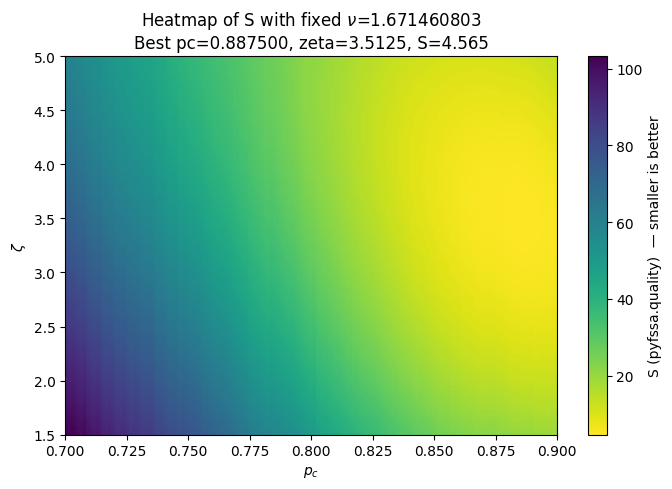

In [8]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
import numpy as np
import fssa
import matplotlib.pyplot as plt

# ======================
# 入力と基本設定
# ======================
npz_path = "TEE_merged.npz"   # あなたの npz
# L はあなたの流儀に合わせて用意（TEE_cols と同数・同順）
# 例: Ah=36,54,72,90,108 → L=sqrt(Ah)
L_list   = [np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
TEE_cols = [2, 3, 4, 5, 6]  # 使う系列（TEE2..TEE6）

# p 窓（あなたのスクリプトに合わせる）
pc_min = 0.75
pc_max = 0.89

# --- ここを "固定ν" にする ---
NU_FIXED = 1.671460803 # 例: 1.80（必要なら 1.7656 などに変更）

# 探索レンジ（必要に応じて広げる）
PC_RANGE   = (0.7, 0.9)   # pc の探索範囲
ZETA_RANGE = (1.5,  5.0)    # zeta の探索範囲
N_PC, N_ZETA = 161, 121     # グリッド解像度

# 誤差フロア（ゼロ重み回避）
ERR_FLOOR_REL = 1e-3

# ======================
# データ読み込み（variance と SE）
# ======================
dat = np.load(npz_path)
pg = dat["pg"]

def key(c): return f"TEE{c}"
a_var  = np.array([dat[f"{key(c)}_var"]     for c in TEE_cols], float)  # shape=(nL,nP)
da_var = np.array([dat[f"{key(c)}_var_err"] for c in TEE_cols], float)

# --- p 窓 ---
mask = (pg >= pc_min) & (pg <= pc_max)
pg_use     = pg[mask]
a_var_use  = a_var[:,  mask]
da_var_use = da_var[:, mask]

# --- p を昇順に並び替え ---
order = np.argsort(pg_use)
pg_use     = pg_use[order]
a_var_use  = a_var_use[:,  order]
da_var_use = da_var_use[:, order]

# --- 誤差フロア ---
eps = ERR_FLOOR_REL * np.nanmedian(np.abs(a_var_use))
da_var_use = np.maximum(da_var_use, eps)

# ======================
# (pc, zeta) グリッドで S=quality を評価
# ======================
pc_vals   = np.linspace(*PC_RANGE,   N_PC)
zeta_vals = np.linspace(*ZETA_RANGE, N_ZETA)
S_grid = np.empty((N_ZETA, N_PC), float); S_grid[:] = np.nan

best = (np.inf, None, None)

for iz, zeta in enumerate(zeta_vals):
    for jp, pc in enumerate(pc_vals):
        # pyfssa のスケール変換（νは固定 → pc と ζ を走査）
        try:
            xs, ys, dys = fssa.scaledata(L_list, pg_use, a_var_use, da_var_use,
                                         pc, NU_FIXED, zeta)
            S = fssa.quality(xs, ys, dys)  # ← pyfssaベースの評価関数
        except Exception:
            S = np.inf
        S_grid[iz, jp] = S
        if np.isfinite(S) and S < best[0]:
            best = (S, pc, zeta)

Smin, pc_best, zeta_best = best
print(f"Best over grid: pc≈{pc_best:.6f}, zeta≈{zeta_best:.4f}, S≈{Smin:.4g} (nu fixed={NU_FIXED})")

# ======================
# 可視化
# ======================
plt.figure(figsize=(7,5))
extent = [pc_vals[0], pc_vals[-1], zeta_vals[0], zeta_vals[-1]]
im = plt.imshow(S_grid, extent=extent, origin='lower', aspect='auto', cmap="viridis_r")
plt.colorbar(im, label="S (pyfssa.quality)  — smaller is better")
plt.xlabel(r"$p_c$"); plt.ylabel(r"$\zeta$")
plt.title(f"Heatmap of S with fixed $\\nu$={NU_FIXED}\nBest pc={pc_best:.6f}, zeta={zeta_best:.4f}, S={Smin:.4g}")
plt.tight_layout()
plt.savefig("S_heatmap_pyfssa_fixed_nu17656.png", dpi=300)
plt.show()

# 保存（再利用用）
np.savez("Sgrid_pyfssa_fixednu.npz",
         pc_vals=pc_vals, zeta_vals=zeta_vals, S_grid=S_grid,
         nu_fixed=NU_FIXED, pc_range=PC_RANGE, zeta_range=ZETA_RANGE,
         pg_window=(pc_min, pc_max),
         L_list=np.array(L_list), TEE_cols=np.array(TEE_cols))
